# MFAA Chapter 11 Laboratory
**Private Credit Engine** (book §11.9)

Price bilateral loans with all four layers: hybrid default intensity, state-dependent recovery, covenant states, prepayment. Organizing display: the spread waterfall. Seed `20261100`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch11
from dataclasses import replace

## 1. E1 — Decompose the 575
The spread waterfall (11.3): expected loss + default-risk premium + illiquidity + covenant rent.

  expected_loss: 114bp
  risk_premium: 156bp
  illiquidity: 200bp
  covenant_rent: 105bp


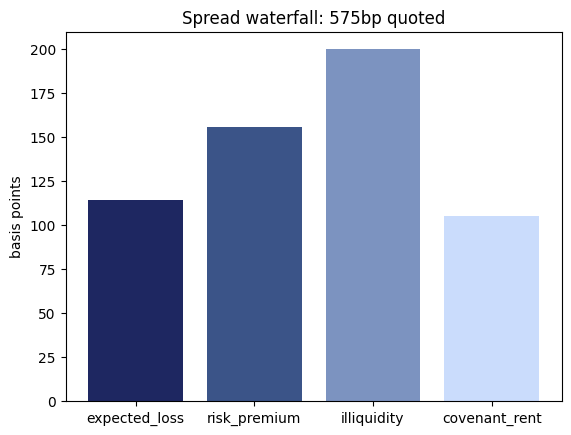

In [2]:
wf = ch11.spread_waterfall(ch11.CreditParams(spread=0.0575))
blocks = ['expected_loss','risk_premium','illiquidity','covenant_rent']
vals = [wf[b]*10000 for b in blocks]
plt.bar(blocks, vals, color=['#1E2761','#3B5488','#7C93C0','#CADCFC'])
plt.ylabel('basis points'); plt.title(f"Spread waterfall: {wf['quoted_spread']*10000:.0f}bp quoted")
for b in blocks: print(f"  {b}: {wf[b]*10000:.0f}bp")

## 2. E4 — Reconcile the committee (P vs Q)
Back out the wedge and its default-risk Sharpe contribution.

In [3]:
rec = ch11.measure_reconciliation(ch11.CreditParams())
print(f"excess return (1-R)(lam_P - lam_Q): {rec['excess_return']:.4f}")
print(f"loss volatility: {rec['loss_volatility']:.4f}")
print(f"default-risk Sharpe: {rec['default_risk_sharpe']:.3f}")

excess return (1-R)(lam_P - lam_Q): 0.0156
loss volatility: 0.0811
default-risk Sharpe: 0.192


## 3. E2 — Price cov-lite: the value of the covenant

In [4]:
cv = ch11.covenant_value(ch11.CreditParams(M=6000))
print(f"full covenant value: {cv['full_covenant_value']:.4f}")
print(f"cov-lite value: {cv['cov_lite_value']:.4f}")
print(f"covenant value: {cv['covenant_value_bps']:.1f} bps")

full covenant value: 1.1766
cov-lite value: 1.1786
covenant value: -19.7 bps


## 4. Validation checks

In [5]:
v = ch11.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_survival PASS
V2_reconciliation PASS
V3_covenant_value PASS
V4_prepay_caps_value PASS
V5_default_monotone PASS
V6_reproducible PASS
ALL: True
